In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

In [2]:
df = pd.read_csv('sales.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)


In [3]:
df.head()

,sales
date,
2022-01-01,1200
2022-01-02,980
2022-01-03,1100
2022-01-04,870
2022-01-05,760


In [4]:
train = df.iloc[:-14]
test  = df.iloc[-14:]
h = len(test)   # Horizon

# Manual SES

In [11]:
def ses_manual(data, alpha, initial=None):
    # data.values converts the pandas series into numpy array because the loop works on raw arrays, not on series objects
    data = data.values

    # Initializes the forecast list with a single starting value. If the initial value is provided, use it. Otherwise the default starting value will be the first actual value (y(0)). The list grows by one element each iteration
    F = [initial if initial is not None else data[0]]

    # Loop from 1 till the end. Starts at F[1] because F[0] is already initialized. We are computing F[1], F[2], F[3]....
    for i in range(1, len(data)):
        # SES formula applied
        F.append(alpha * data[i-1] + (1-alpha) * F[i-1])
    # Converts the list into a numpy array
    return np.array(F)

In [12]:
alpha = 0.2     # value of the smoothing parameter

In [16]:
smoothed = ses_manual(train['sales'], alpha)    # manually computed SES
smoothed

array([1200.        , 1200.        , 1156.        , 1144.8       ,
       1089.84      , 1023.872     , 1109.0976    , 1207.27808   ,
       1195.822464  , 1160.6579712 , 1144.52637696, 1101.62110157,
       1051.29688125, 1145.037505  , 1246.030004  , 1232.8240032 ,
       1196.25920256, 1181.00736205, 1136.80588964, 1085.44471171,
       1184.35576937, 1287.4846155 , 1273.9876924 , 1237.19015392,
       1221.75212313, 1177.40169851, 1125.92135881, 1224.73708704,
       1329.78966964, 1315.83173571, 1278.66538857, 1262.93231085,
       1220.34584868, 1170.27667895, 1108.22134316, 1182.57707453,
       1262.06165962, 1247.6493277 , 1210.11946216, 1194.09556973,
       1151.27645578, 1101.02116462, 1190.8169317 , 1288.65354536,
       1276.92283629, 1401.53826903, 1351.23061522, 1282.98449218,
       1212.38759374, 1289.91007499, 1377.92806   , 1356.342448  ,
       1313.0739584 , 1292.45916672, 1245.96733337, 1190.7738667 ,
       1280.61909336, 1380.49527469, 1364.39621975, 1325.51697

In [18]:
# train["sales"].iloc[-1] gets the last actual value from the training data
# smoothed[-1] gets the last value from the forecasted array
# forecasted value is then calculated by applying the formula
fc_val = alpha * train['sales'].iloc[-1] + (1 - alpha) * smoothed[-1]
fc_val

np.float64(3208.574562397353)

In [21]:
# Repeat the forecasted value calculated above h times (14 times). Because SES is a level only model with no trend component, every future step gets the same forecast  value. THe forecast is flat
fc_final = pd.Series(
    np.repeat(fc_val, h),
    index=test.index
)

In [22]:
fc_final

date
2022-12-18    3208.574562
2022-12-19    3208.574562
2022-12-20    3208.574562
2022-12-21    3208.574562
2022-12-22    3208.574562
2022-12-23    3208.574562
2022-12-24    3208.574562
2022-12-25    3208.574562
2022-12-26    3208.574562
2022-12-27    3208.574562
2022-12-28    3208.574562
2022-12-29    3208.574562
2022-12-30    3208.574562
2022-12-31    3208.574562
dtype: float64

# Statsmodels SES

In [23]:
# Creating the SES object
# initialization_method = "estimated" tells statsmodels to treat the initial forecast F[1] as a parameter to be estimated from the data alongside a
model = SimpleExpSmoothing(train['sales'],initialization_method='estimated')

# Fits the model.  optimized = Trye tells statsmodels to use an optimiser to find the value of α that minimises the sum of squared in-sample errors. It tries many α values, evaluates SSE at each, and returns the best one. This is always preferred over manually guessing α.
fitted  = model.fit(optimized=True)

# fitted.forecast(h) generates 14 forecast values. Returns a pandas series with the correct future index. No need to manually set
fc_stats   = fitted.forecast(h)

# This extracts the optimal alpha that the optimizer found. "smoothing_level" is statsmodels internal name for alpha in exponential smoothing models
opt_alpha  = fitted.params['smoothing_level']

D:\Complete ML\FastAPI\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [26]:
print(f"Manual α={alpha}   MAE: {np.mean(np.abs(fc_final - test['sales'])):.2f}")
print(f"Optimal α={opt_alpha:.3f}  MAE: {np.mean(np.abs(fc_stats  - test['sales'])):.2f}")

Manual α=0.2   MAE: 433.88
Optimal α=0.079  MAE: 417.14


In [ ]:
# Comparing these two MAE values tells you directly how much benefit the optimised α provides over the manually chosen α=0.3. If the optimised version gives lower MAE, the optimiser found a better α than your guess. If they are similar, α=0.3 happened to be close to optimal for this series.

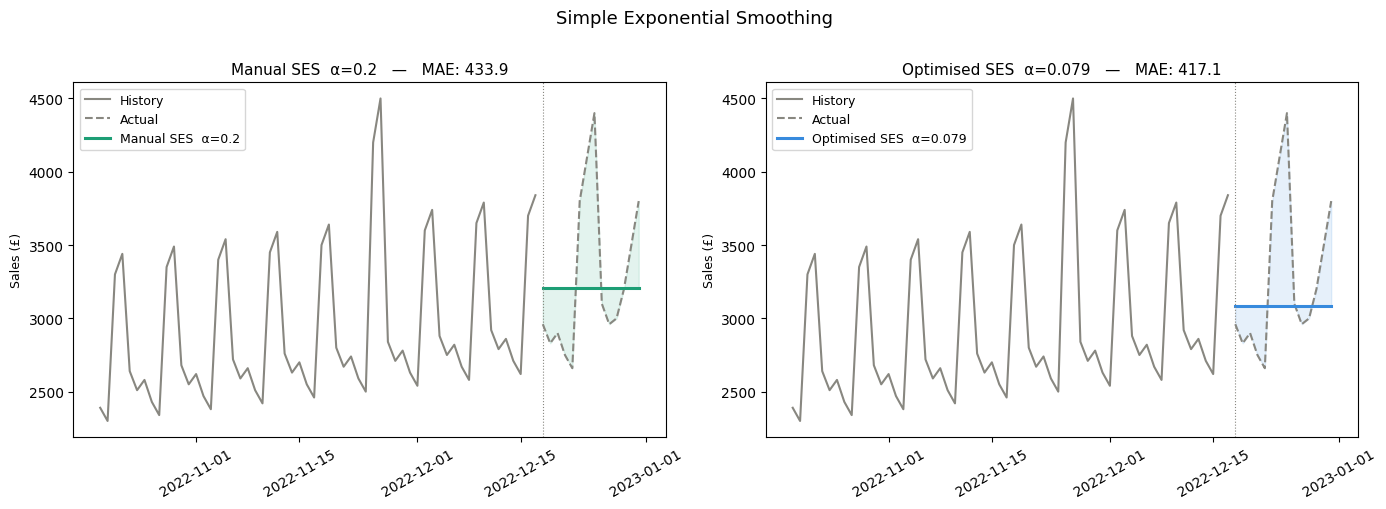

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_plot = train['sales'].iloc[-60:]

for ax, (fc, label, alpha_val, color) in zip(axes, [
    (fc_final, f'Manual SES  α={alpha}',         alpha,     '#1D9E75'),
    (fc_stats,  f'Optimised SES  α={opt_alpha:.3f}', opt_alpha, '#378ADD'),
]):
    ax.plot(train_plot.index, train_plot.values,
            color='#888780', linewidth=1.5, label='History')
    ax.plot(test.index, test['sales'].values,
            color='#888780', linewidth=1.5, linestyle='--', label='Actual')
    ax.plot(test.index, fc.values,
            color=color, linewidth=2.2, label=label)
    ax.fill_between(test.index, fc.values, test['sales'].values,
                    alpha=0.12, color=color)
    ax.axvline(test.index[0], color='#888780', linewidth=0.8, linestyle=':')
    mae_val = np.mean(np.abs(fc - test['sales']))
    ax.set_title(f'{label}   —   MAE: {mae_val:.1f}', fontsize=11)
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('Sales (£)', fontsize=9)

plt.suptitle('Simple Exponential Smoothing', fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()
plt.savefig('ses.png', dpi=150, bbox_inches='tight')
plt.show()